In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
pd.set_option('display.max_columns', None)

In [100]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv').drop_duplicates()

In [101]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,smart world orchard,sector 61,1.41,12250.0,1151.0,Built Up area: 1150 (106.84 sq.m.),2,2,2,2.0,NaN,Under Construction,Situated in prime location of sector 61 on gol...,NaN,1150.0,NaN,1,0,0,0,0,1,76
1,flat,dlf the primus,sector 82a,2.85,10936.0,2606.0,Super Built up area 2606(242.11 sq.m.)Carpet a...,4,4,3+,2.0,North-East,New Property,A north facing 4 bhk resale flat is available ...,2606.0,NaN,1800.0,0,1,0,0,0,2,174
2,flat,bptp astaire gardens,sector 70a,1.70,8947.0,1900.0,Carpet area: 1900 (176.52 sq.m.),4,3,3,1.0,North-East,Relatively New,"On gurgaon spr, good potential as this area is...",NaN,NaN,1900.0,0,0,0,0,0,0,49
3,flat,shapoorji pallonji joyville gurugram,sector 102,0.95,10383.0,915.0,Built Up area: 915 (85.01 sq.m.)Carpet area: 8...,2,2,2,14.0,North-West,Undefined,"Club house, mini theater, squash court, swimmi...",NaN,915.0,858.0,0,0,0,0,0,1,0
4,house,independent,sector 7,1.20,11194.0,1072.0,Built Up area: 1072 (99.59 sq.m.),5,4,2,3.0,NaN,Undefined,5bhk residential house for resale in jyoti par...,NaN,1072.0,NaN,0,0,0,0,0,1,0


In [102]:
df.shape

(3678, 24)

In [103]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'description', 'super_built_up_area', 'built_up_area',
       'carpet_area', 'study room', 'servant room', 'store room', 'pooja room',
       'others', 'furnishing_type', 'luxury_score'],
      dtype='object')

C:\Users\DELL\AppData\Local\Temp\ipykernel_14896\444587821.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

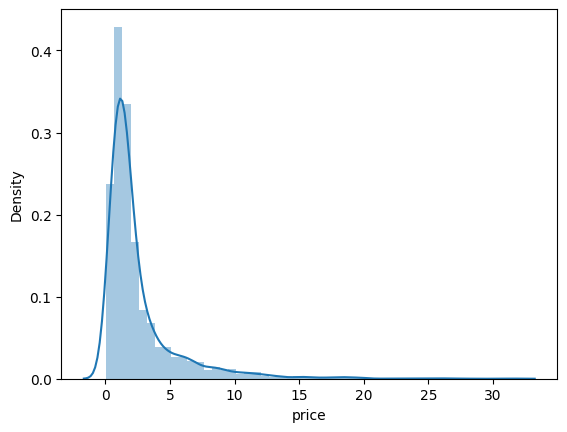

In [104]:
sns.distplot(df['price'])

<Axes: ylabel='price'>

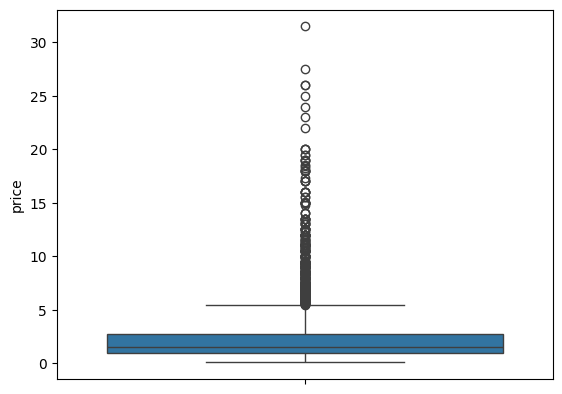

In [105]:
sns.boxplot(df['price'])

In [106]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats


(425,
 count    425.000000
 mean       9.235624
 std        4.065259
 min        5.460000
 25%        6.460000
 50%        8.000000
 75%       10.750000
 max       31.500000
 Name: price, dtype: float64)

In [107]:
outliers.sort_values('price',ascending=False).head(20)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1852,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,3.0,North-East,Moderately Old,Ultra modern super luxury duplex bungalow with...,NaN,9000.0,NaN,1,1,1,1,0,2,74
1604,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,Sushant lok 1 very prime location. This villa ...,NaN,11286.0,NaN,1,1,0,1,1,0,42
1876,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,505 sq.Y 6 bhk luxury villa \nIn dlf phase 1\n...,NaN,4545.0,NaN,1,1,0,1,1,0,138
836,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,"Dlf phase 1 very prime location , this buildin...",NaN,400.0,350.0,1,1,1,1,0,0,72
186,house,suncity township,sector 54,25.00,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,North,Moderately Old,"Suncity township in sector 54, gurgaon is a re...",NaN,1000.0,NaN,1,1,1,1,0,1,0
2557,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,Emaar palm spring sector-54 (Villa) 400 gaj ba...,NaN,400.0,NaN,1,1,0,1,0,0,122
2907,house,independent,sector 26,23.00,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,South-West,Relatively New,1000 sq yards well maintained build up house a...,NaN,9000.0,NaN,1,1,1,1,0,0,145
747,house,vipul tatvam villa,sector 48,22.00,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5,6,3,3.0,NaN,Moderately Old,A 1000 sqyd villa available for sale. The vill...,NaN,1000.0,NaN,0,1,0,0,0,1,54
2889,house,independent,sector 26,20.00,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,"West facing kothi , area- 500 sq yard, \n5bhk-...",NaN,4500.0,NaN,0,1,0,1,0,2,97
952,house,dlf city plots,sector 26,20.00,44265.0,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,4.0,North-East,New Property,North east facing\nNear to paschim marg\nPosh ...,NaN,4518.0,NaN,1,1,1,1,0,0,153


In [108]:
# on the basis of price col we can say that there are some genuine outliers but there are some data erros as well

### Price_per_sqft

C:\Users\DELL\AppData\Local\Temp\ipykernel_14896\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

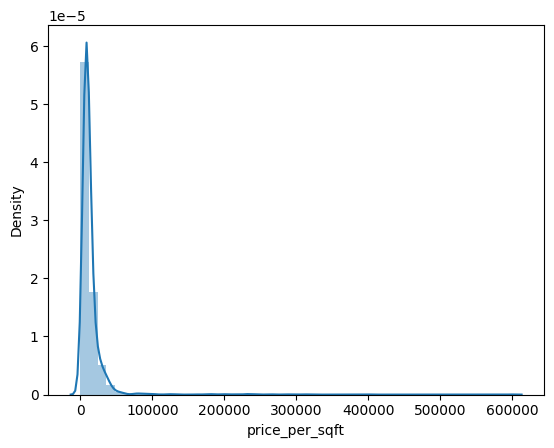

In [109]:
sns.distplot(df['price_per_sqft'])

<Axes: ylabel='price_per_sqft'>

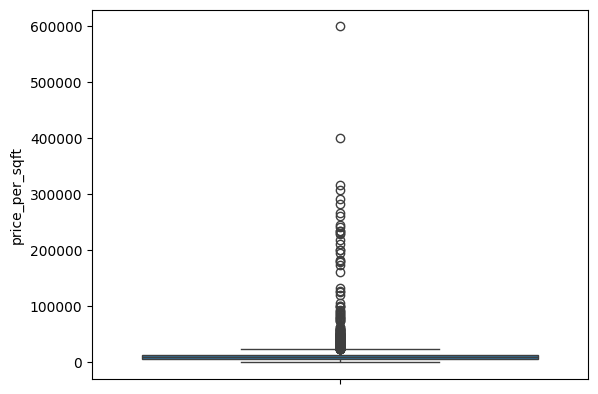

In [110]:
sns.boxplot(df['price_per_sqft'])

In [111]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(354,
 count       354.000000
 mean      52592.612994
 std       61150.458507
 min       24489.000000
 25%       28208.250000
 50%       33368.500000
 75%       41982.250000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [112]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

C:\Users\DELL\AppData\Local\Temp\ipykernel_14896\205471443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [113]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

C:\Users\DELL\AppData\Local\Temp\ipykernel_14896\3686006548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [114]:
outliers_sqft['price_per_sqft'].describe()

count      354.000000
mean     29357.906780
std      12403.077309
min       2723.000000
25%      25562.000000
50%      29870.500000
75%      35549.500000
max      82540.000000
Name: price_per_sqft, dtype: float64

In [115]:
df.update(outliers_sqft)

C:\Users\DELL\AppData\Local\Temp\ipykernel_14896\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

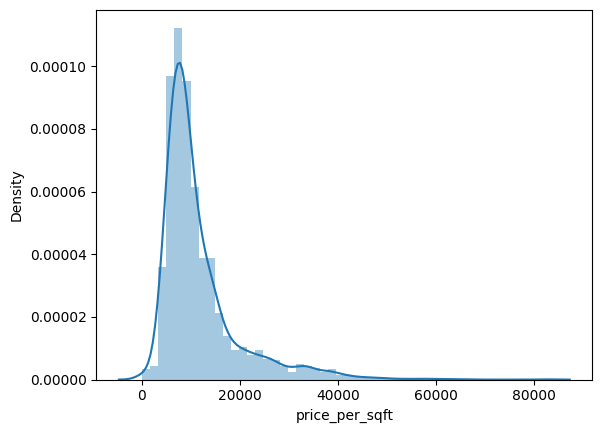

In [116]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

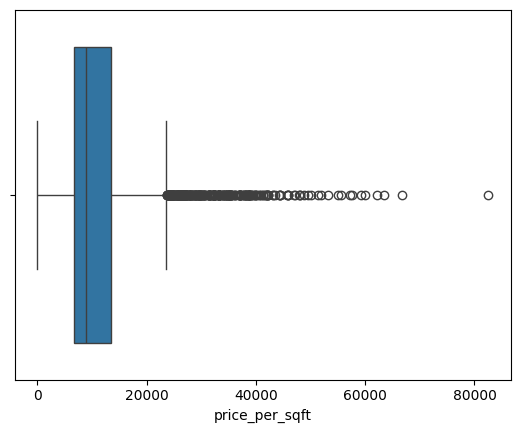

In [117]:
sns.boxplot(x=df['price_per_sqft'])

In [118]:
df[df['price_per_sqft']>50000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
150,house,emaar the palm springs,sector 54,14.00,62222.0,2250.0,Plot area 250(209.03 sq.m.),4,5,3+,2.0,North,Old Property,Bathrooms\n Imported marble flooring in master...,NaN,2250.0,NaN,1,1,0,0,0,0,160
836,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,"Dlf phase 1 very prime location , this buildin...",NaN,400.0,350.0,1,1,1,1,0,0,72
1222,house,project housing board colony,sector 31,8.00,63492.0,1260.0,Built Up area: 140 (117.06 sq.m.),2,1,0,1.0,NaN,Undefined,2bhk residential house for resale in project h...,NaN,140.0,NaN,0,0,0,0,0,1,0
1476,flat,unitech vistas,sector 70,9.00,57508.0,1565.0,Built Up area: 1565 (145.39 sq.m.),3,3,0,7.0,NaN,Undefined,Best in class property available at sector 70 ...,NaN,1565.0,NaN,0,0,0,0,0,1,0
1876,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,505 sq.Y 6 bhk luxury villa \nIn dlf phase 1\n...,NaN,4545.0,NaN,1,1,0,1,1,0,138
1925,house,malibu towne,sector 47,8.50,53125.0,1600.0,Built Up area: 1600 (148.64 sq.m.),12,12,3+,4.0,North,New Property,It's a wholly distinctive home with three open...,NaN,1600.0,NaN,0,0,0,0,0,0,99
1978,house,unitech escape,sector 50,10.80,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 ...,4,4,3,2.0,North,Relatively New,The villa is very good location and 100% power...,NaN,250.0,200.0,1,1,1,1,0,0,103
2055,house,independent,sector 25,16.00,59259.0,2700.0,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16,16,3+,4.0,West,New Property,"Dlf phase 2 very prime location , this buildin...",NaN,325.0,300.0,1,1,1,1,0,0,72
2149,house,emaar mgf marbella,sector 66,18.00,55556.0,3240.0,Plot area 360(301.01 sq.m.),4,4,3+,3.0,East,Moderately Old,Check out this 4 bhk house for sale in sector ...,NaN,3240.0,NaN,1,1,0,1,0,2,75
2272,house,nul,sector 28,12.50,51440.0,2430.0,Plot area 270(225.75 sq.m.),16,17,3+,4.0,South,Relatively New,270 sq yard 4bhk par floor brand new building ...,NaN,2430.0,NaN,1,1,0,1,1,2,137


In [119]:
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

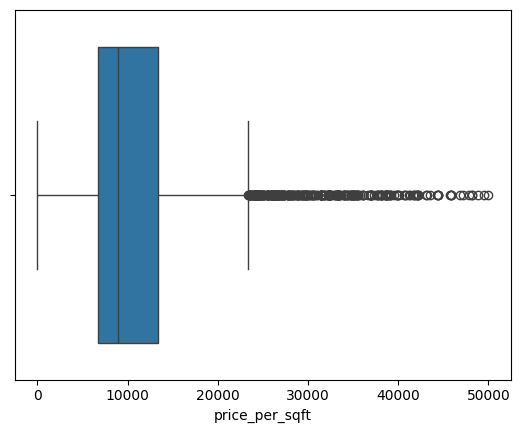

In [120]:
sns.boxplot(x=df['price_per_sqft'])

### Area

C:\Users\DELL\AppData\Local\Temp\ipykernel_14896\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

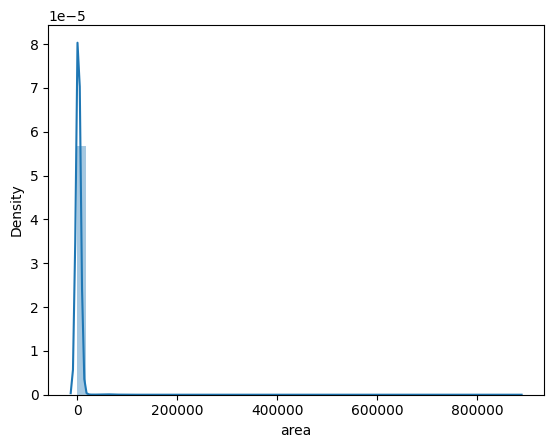

In [121]:
sns.distplot(df['area'])

<Axes: ylabel='area'>

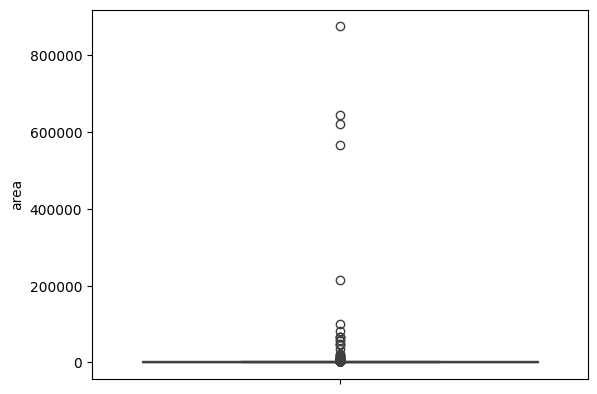

In [122]:
sns.boxplot(df['area'])

In [123]:
df['area'].describe()

count      3648.000000
mean       2947.064693
std       23205.046192
min         145.000000
25%        1261.750000
50%        1750.000000
75%        2350.000000
max      875000.000000
Name: area, dtype: float64

In [124]:
df[df['area'] > 100000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
299,house,independent,sector 50,5.00,232.0,215517.0,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,New Property,This 6 bhk house for sale in sector 50 gurgaon...,NaN,2.0,NaN,1,1,0,1,1,0,0
979,flat,signature the roselia,sector 95,0.45,7.0,642857.0,Carpet area: 569243 (52884.41 sq.m.),2,2,2,2.0,South-West,New Property,"Highly ventilated and trusted builder, spaciou...",NaN,NaN,569243.0,0,0,0,0,0,1,76
2307,flat,ramsons kshitij,sector 95,0.31,5.0,620000.0,Carpet area: 607936 (56479.1 sq.m.),2,2,1,1.0,North-East,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,607936.0,1,0,0,0,1,1,65
3216,flat,signature global solera 2,sector 107,0.51,9.0,566667.0,Carpet area: 514396 (47788.95 sq.m.),2,2,1,3.0,North,New Property,It is near metro it is very beautiful,NaN,NaN,514396.0,0,0,0,0,0,1,44
3344,flat,hcbs sports ville,sohna road,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,2,8.0,NaN,Relatively New,"View is awesome, towards the aravalli and fres...",NaN,737147.0,NaN,0,0,0,0,0,2,44


In [125]:
df = df[df['area'] < 100000]

C:\Users\DELL\AppData\Local\Temp\ipykernel_14896\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

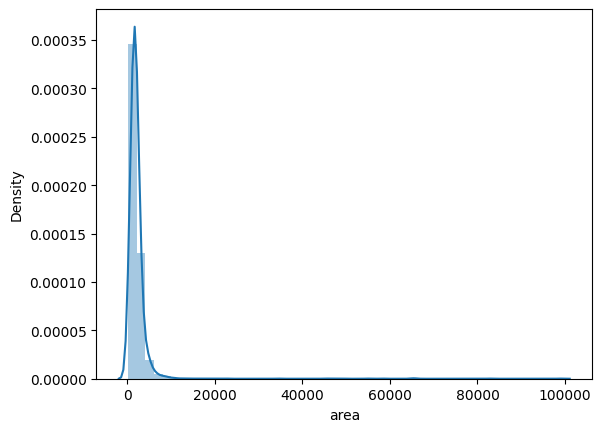

In [126]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

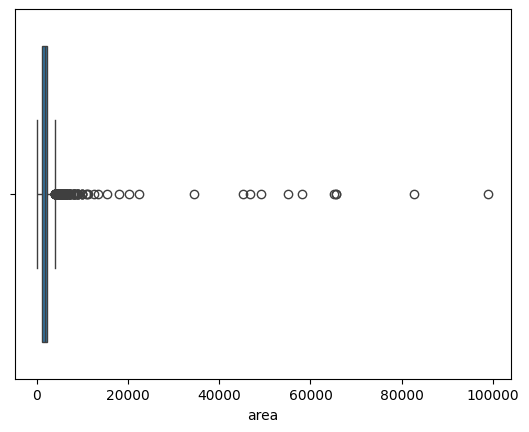

In [127]:
sns.boxplot(x=df['area'])

In [128]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3153,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,Dlf city phase 1 a block duplex kothi sale in ...,NaN,NaN,11000.00,0,1,1,1,0,0,60
1749,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,Next to gurgaon bus depot. 10 mins walking dis...,NaN,115.0,NaN,0,0,0,0,1,1,7
2916,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,Its rera approved and best built quality made ...,NaN,NaN,64529.00,1,0,0,0,0,1,15
1260,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,64412.00,0,0,0,0,0,1,51
3568,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,Best in class property available at dlf city p...,NaN,NaN,7250.00,0,0,0,0,0,1,0
324,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,Near to dwarka expressway\nNear to airport,NaN,NaN,58141.00,0,0,0,0,0,1,15
1502,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,54917.00,0,0,0,0,0,1,37
2456,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,This project is signature builder. On road soc...,NaN,NaN,48811.00,1,0,0,0,0,1,37
1768,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,"Floorwise builtup house with basement, stilt w...",NaN,5800.0,5200.00,0,1,1,0,0,0,109
117,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.0,North-West,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,45966.00,0,0,0,0,1,1,33


In [129]:
df.drop(index=[818, 1796, 1123, 2, 2356, 115, 3649, 2503, 1471], inplace=True)

In [130]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3153,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,Dlf city phase 1 a block duplex kothi sale in ...,NaN,NaN,11000.00,0,1,1,1,0,0,60
1749,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,Next to gurgaon bus depot. 10 mins walking dis...,NaN,115.0,NaN,0,0,0,0,1,1,7
2916,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,Its rera approved and best built quality made ...,NaN,NaN,64529.00,1,0,0,0,0,1,15
1260,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,64412.00,0,0,0,0,0,1,51
3568,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,Best in class property available at dlf city p...,NaN,NaN,7250.00,0,0,0,0,0,1,0
324,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,Near to dwarka expressway\nNear to airport,NaN,NaN,58141.00,0,0,0,0,0,1,15
1502,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,54917.00,0,0,0,0,0,1,37
2456,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,This project is signature builder. On road soc...,NaN,NaN,48811.00,1,0,0,0,0,1,37
1768,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,"Floorwise builtup house with basement, stilt w...",NaN,5800.0,5200.00,0,1,1,0,0,0,109
117,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.0,North-West,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,45966.00,0,0,0,0,1,1,33


In [131]:
df.loc[48,'area'] = 115*9
df.loc[300,'area'] = 7250
df.loc[2666,'area'] = 5800
df.loc[1358,'area'] = 2660
df.loc[3195,'area'] = 2850
df.loc[2131,'area'] = 1812
df.loc[3088,'area'] = 2160
df.loc[3444,'area'] = 1175

C:\Users\DELL\AppData\Local\Temp\ipykernel_14896\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

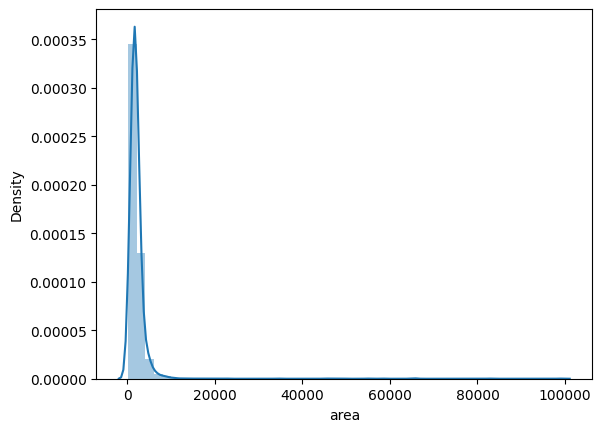

In [132]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

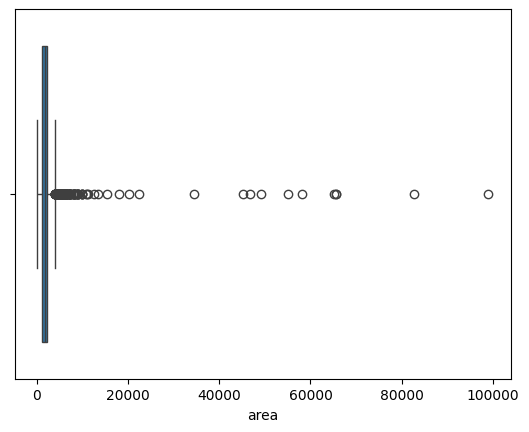

In [133]:
sns.boxplot(x=df['area'])

In [134]:
df['area'].describe()

count     3635.000000
mean      2153.091609
std       3628.627484
min        145.000000
25%       1261.000000
50%       1750.000000
75%       2343.500000
max      98978.000000
Name: area, dtype: float64

### Bedroom

C:\Users\DELL\AppData\Local\Temp\ipykernel_14896\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

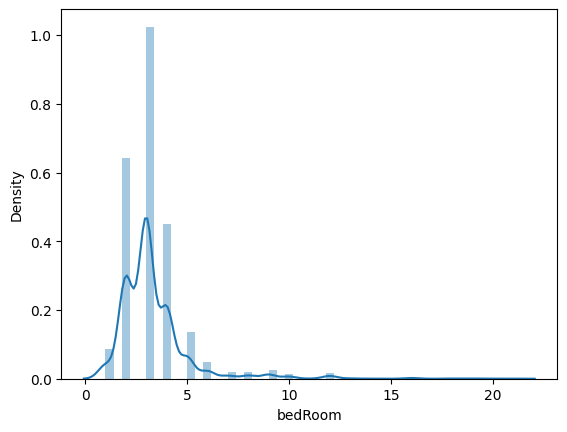

In [135]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

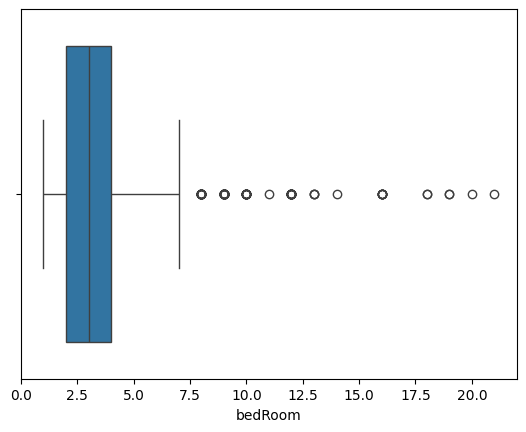

In [136]:
sns.boxplot(x=df['bedRoom'])

In [137]:
df['bedRoom'].describe()

count    3634.000000
mean        3.327463
std         1.822144
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
Name: bedRoom, dtype: float64

In [138]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
752,house,independent,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21.0,21.0,3+,5.0,North,Relatively New,"129 sq yd plot size. 5 floors built up , fully...",NaN,1161.0,NaN,0.0,1.0,0.0,0.0,0.0,2.0,49.0
3132,house,independent,sector 43,4.50,39062.0,1152.0,Plot area 128(107.02 sq.m.),20.0,20.0,3+,4.0,East,Relatively New,Best for investment purpose. 3l rupees monthly...,NaN,1152.0,NaN,0.0,1.0,0.0,0.0,0.0,2.0,22.0
943,house,independent,sector 17a,3.93,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19.0,17.0,3,4.0,North-West,Relatively New,"8% return yearly, very safe sector, supportive...",NaN,1622.0,NaN,1.0,1.0,1.0,1.0,0.0,1.0,74.0
1673,house,independent,sector 17a,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19.0,17.0,3+,5.0,North-West,Relatively New,The building is equipped with modern fittings....,NaN,7500.0,NaN,1.0,0.0,1.0,0.0,0.0,1.0,68.0
2264,house,independent,sector 54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18.0,18.0,3+,4.0,South-West,Relatively New,18 bed room newly built up in 160 yds plot is ...,NaN,1440.0,NaN,0.0,1.0,0.0,0.0,0.0,2.0,70.0
955,house,private house,sector 55,7.05,46906.0,1503.0,Plot area 167(139.63 sq.m.),18.0,18.0,3+,4.0,North-East,Relatively New,18furnished rooms with all interior and goods ...,NaN,1503.0,NaN,0.0,0.0,0.0,0.0,1.0,2.0,57.0
1721,house,independent,sector 40,12.00,38986.0,3078.0,Plot area 342(285.96 sq.m.),16.0,16.0,3+,4.0,NaN,New Property,Ready to move in simplex kothi available for s...,NaN,3078.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0
1038,house,luxury dlf city floors,sector 26,20.00,48888.0,4091.0,Plot area 500(418.06 sq.m.),16.0,16.0,3+,4.0,NaN,New Property,Prime location on dlf phase - 1 builder floor ...,NaN,500.0,NaN,0.0,1.0,0.0,0.0,0.0,0.0,31.0
952,house,dlf city plots,sector 26,20.00,44267.0,4518.0,Plot area 502(419.74 sq.m.),16.0,20.0,3+,4.0,North-East,New Property,North east facing\nNear to paschim marg\nPosh ...,NaN,4518.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,153.0
3047,house,independent,sector 55,9.19,34037.0,2700.0,Plot area 300(250.84 sq.m.),16.0,18.0,2,4.0,West,New Property,This 16 bhk house for sale in sushant lok phas...,NaN,2700.0,NaN,0.0,1.0,0.0,1.0,0.0,0.0,49.0


In [139]:
df = df[df['bedRoom'] <= 10]

In [140]:
df.shape

(3590, 24)

C:\Users\DELL\AppData\Local\Temp\ipykernel_14896\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

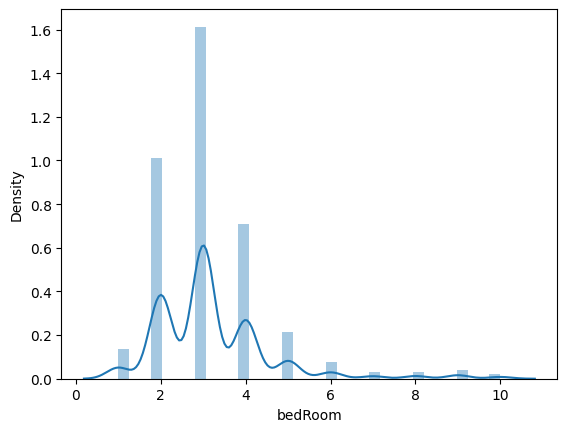

In [141]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

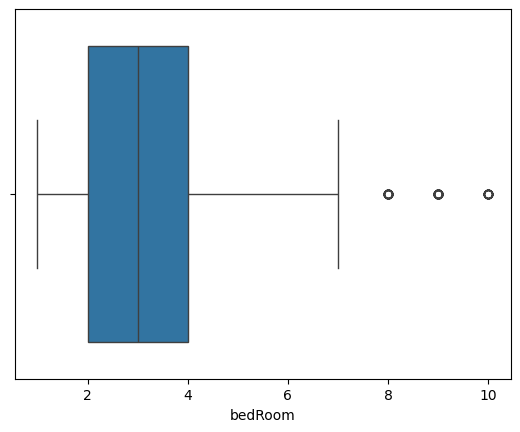

In [142]:
sns.boxplot(x=df['bedRoom'])

In [143]:
df['bedRoom'].describe()

count    3590.000000
mean        3.200279
std         1.392473
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedRoom, dtype: float64

### Bathroom

C:\Users\DELL\AppData\Local\Temp\ipykernel_14896\2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

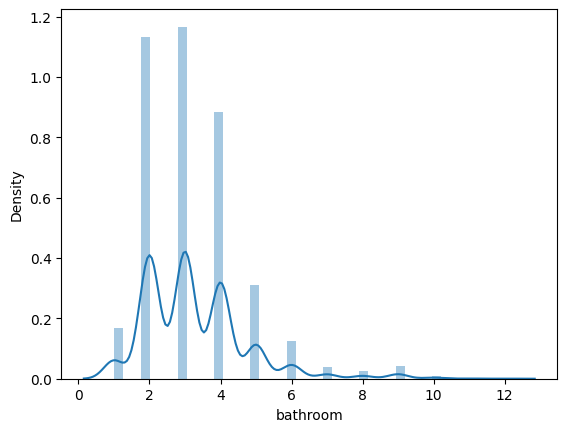

In [144]:
sns.distplot(df['bathroom'])

In [146]:
df['bathroom'].describe()

count    3590.000000
mean        3.269081
std         1.455772
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        12.000000
Name: bathroom, dtype: float64

<Axes: xlabel='bathroom'>

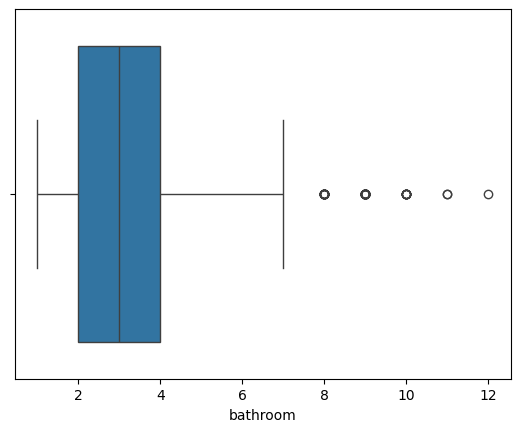

In [147]:
sns.boxplot(x=df['bathroom'])

In [148]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2411,house,adani brahma samsara,sector 60,18.02,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9.0,12.0,3+,3.0,North-East,Relatively New,An impeccable opportunity is here for those wh...,NaN,6390.0,NaN,0.0,1.0,0.0,0.0,0.0,0.0,146.0
1093,house,independent,sector 24,11.00,28902.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8.0,11.0,3+,3.0,East,Old Property,Independent house available for sale.,NaN,5000.0,NaN,1.0,1.0,0.0,1.0,1.0,0.0,39.0
2837,house,independent,sector 39,7.00,10000.0,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10.0,11.0,3+,4.0,South-East,Relatively New,"Luxury house 10 bhk, floor wise, basement plus...",NaN,7000.0,NaN,0.0,0.0,0.0,1.0,0.0,2.0,38.0


In [149]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,smart world orchard,sector 61,1.41,12250.0,1151.0,Built Up area: 1150 (106.84 sq.m.),2.0,2.0,2,2.0,NaN,Under Construction,Situated in prime location of sector 61 on gol...,NaN,1150.0,NaN,1.0,0.0,0.0,0.0,0.0,1.0,76.0
1,flat,dlf the primus,sector 82a,2.85,10936.0,2606.0,Super Built up area 2606(242.11 sq.m.)Carpet a...,4.0,4.0,3+,2.0,North-East,New Property,A north facing 4 bhk resale flat is available ...,2606.0,NaN,1800.0,0.0,1.0,0.0,0.0,0.0,2.0,174.0
3,flat,shapoorji pallonji joyville gurugram,sector 102,0.95,10383.0,915.0,Built Up area: 915 (85.01 sq.m.)Carpet area: 8...,2.0,2.0,2,14.0,North-West,Undefined,"Club house, mini theater, squash court, swimmi...",NaN,915.0,858.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,house,independent,sector 7,1.20,11194.0,1072.0,Built Up area: 1072 (99.59 sq.m.),5.0,4.0,2,3.0,NaN,Undefined,5bhk residential house for resale in jyoti par...,NaN,1072.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,flat,hcbs sports ville,sohna road,0.27,4345.0,621.0,Built Up area: 619 (57.51 sq.m.),2.0,2.0,2,10.0,NaN,Relatively New,Raw flat as given by builder. Good location ne...,NaN,619.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,43.0


### super built up area

C:\Users\DELL\AppData\Local\Temp\ipykernel_14896\4184943455.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])


<Axes: xlabel='super_built_up_area', ylabel='Density'>

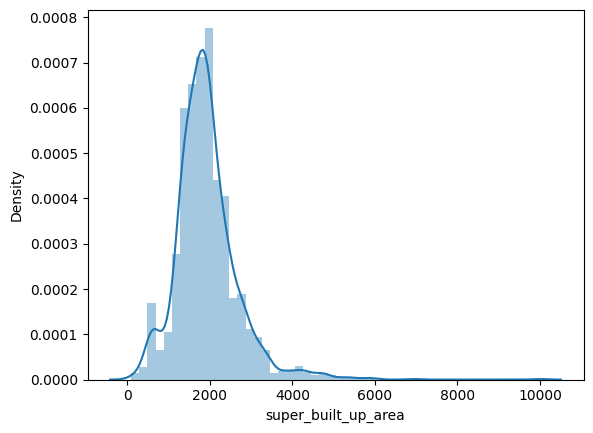

In [150]:
sns.distplot(df['super_built_up_area'])

<Axes: xlabel='super_built_up_area'>

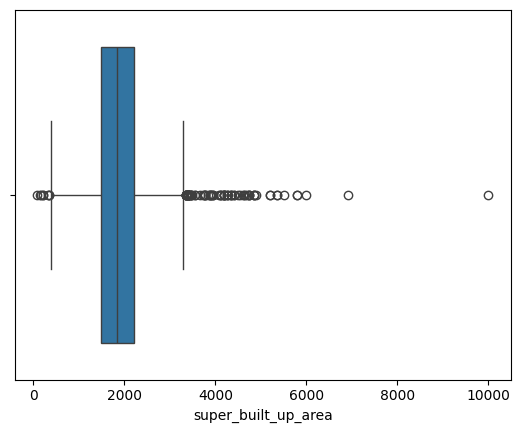

In [151]:
sns.boxplot(x=df['super_built_up_area'])

In [152]:
df[df['super_built_up_area'] > 6000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3456,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4.0,4.0,3+,19.0,North,Relatively New,Semi furnished 4bhk 6926sqft penthouse with pe...,6926.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,140.0
3641,flat,krrish provence estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5.0,6.0,3+,23.0,North-East,Relatively New,"It is a beautiful penthouse with 10,000/- Sqft...",10000.0,NaN,NaN,0.0,1.0,0.0,1.0,1.0,1.0,49.0


### built up area

C:\Users\DELL\AppData\Local\Temp\ipykernel_14896\3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

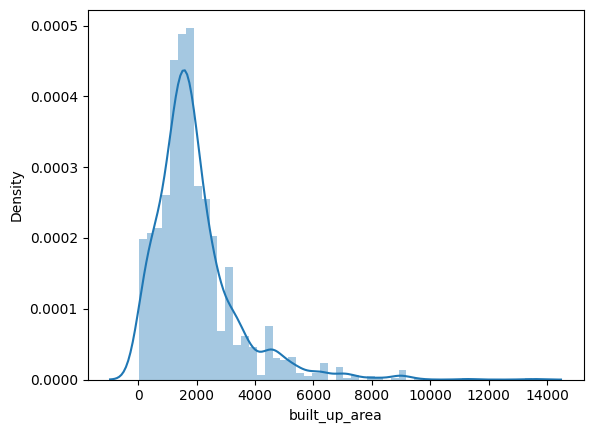

In [153]:
sns.distplot(df['built_up_area'])

<Axes: xlabel='built_up_area'>

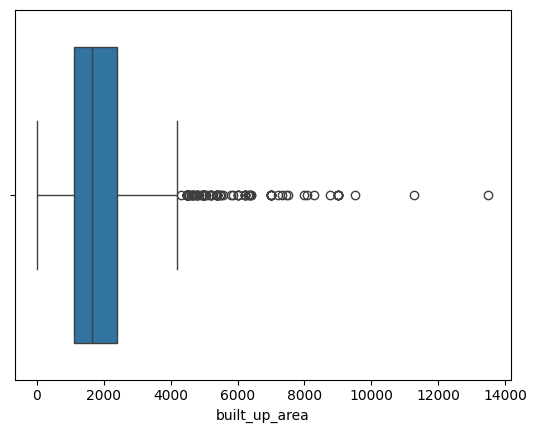

In [154]:
sns.boxplot(x=df['built_up_area'])

In [155]:
df[df['built_up_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1604,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6.0,7.0,3+,3.0,North-East,Relatively New,Sushant lok 1 very prime location. This villa ...,NaN,11286.0,NaN,1.0,1.0,0.0,1.0,1.0,0.0,42.0
2370,house,independent,sector 4,0.85,630.0,13492.0,Plot area 1500(1254.19 sq.m.),3.0,3.0,1,1.0,North,Relatively New,Looking to buy an independent house in gurgaon...,NaN,13500.0,NaN,0.0,0.0,0.0,0.0,1.0,1.0,0.0


### carpet area

C:\Users\DELL\AppData\Local\Temp\ipykernel_14896\3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

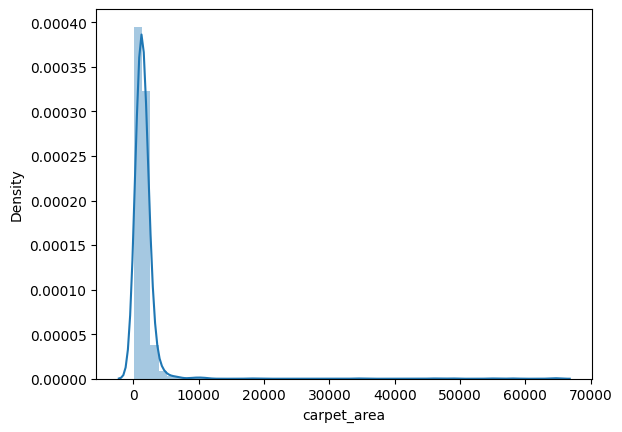

In [156]:
sns.distplot(df['carpet_area'])

<Axes: xlabel='carpet_area'>

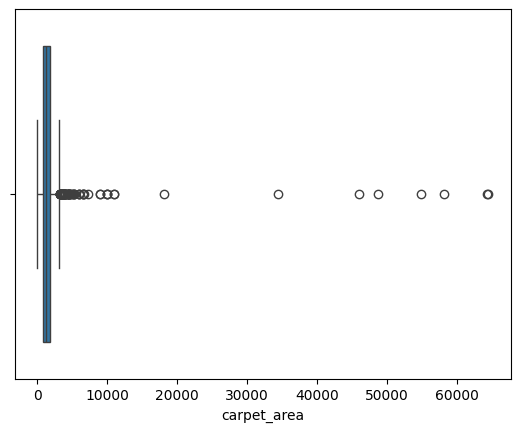

In [157]:
sns.boxplot(x=df['carpet_area'])

In [160]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
117,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2.0,2.0,1,10.0,North-West,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,45966.0,0.0,0.0,0.0,0.0,1.0,1.0,33.0
324,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2.0,2.0,1,0.0,NaN,Under Construction,Near to dwarka expressway\nNear to airport,NaN,NaN,58141.0,0.0,0.0,0.0,0.0,0.0,1.0,15.0
1167,flat,m3m golfestate,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4.0,4.0,3,13.0,North,Moderately Old,4 bedroom 11000 sq.Ft. Middle floor penthouse ...,NaN,NaN,11000.0,0.0,1.0,0.0,0.0,0.0,1.0,60.0
1220,flat,rof ananda,sector 95,0.21,61.0,34426.0,Carpet area: 34401 (3195.96 sq.m.),1.0,1.0,1,13.0,North,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,34401.0,0.0,0.0,0.0,0.0,0.0,1.0,68.0
1260,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3.0,2.0,1,12.0,North,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,64412.0,0.0,0.0,0.0,0.0,0.0,1.0,51.0
1502,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2.0,2.0,1,13.0,South-West,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,54917.0,0.0,0.0,0.0,0.0,0.0,1.0,37.0
1506,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4.0,5.0,3+,16.0,North-East,Under Construction,Godrej as a brand and very few densed society,NaN,NaN,18122.0,1.0,0.0,0.0,1.0,1.0,0.0,44.0
2456,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1.0,1.0,2,1.0,North-West,Relatively New,This project is signature builder. On road soc...,NaN,NaN,48811.0,1.0,0.0,0.0,0.0,0.0,1.0,37.0
2916,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2.0,2.0,2,10.0,East,New Property,Its rera approved and best built quality made ...,NaN,NaN,64529.0,1.0,0.0,0.0,0.0,0.0,1.0,15.0
3153,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6.0,8.0,3+,4.0,South,Relatively New,Dlf city phase 1 a block duplex kothi sale in ...,NaN,NaN,11000.0,0.0,1.0,1.0,1.0,0.0,0.0,60.0


In [161]:
df.loc[2131,'carpet_area'] = 1812

In [162]:
df[df['carpet_area'] > 10000]


,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
117,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2.0,2.0,1,10.0,North-West,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,45966.0,0.0,0.0,0.0,0.0,1.0,1.0,33.0
324,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2.0,2.0,1,0.0,NaN,Under Construction,Near to dwarka expressway\nNear to airport,NaN,NaN,58141.0,0.0,0.0,0.0,0.0,0.0,1.0,15.0
1167,flat,m3m golfestate,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4.0,4.0,3,13.0,North,Moderately Old,4 bedroom 11000 sq.Ft. Middle floor penthouse ...,NaN,NaN,11000.0,0.0,1.0,0.0,0.0,0.0,1.0,60.0
1220,flat,rof ananda,sector 95,0.21,61.0,34426.0,Carpet area: 34401 (3195.96 sq.m.),1.0,1.0,1,13.0,North,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,34401.0,0.0,0.0,0.0,0.0,0.0,1.0,68.0
1260,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3.0,2.0,1,12.0,North,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,64412.0,0.0,0.0,0.0,0.0,0.0,1.0,51.0
1502,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2.0,2.0,1,13.0,South-West,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,54917.0,0.0,0.0,0.0,0.0,0.0,1.0,37.0
1506,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4.0,5.0,3+,16.0,North-East,Under Construction,Godrej as a brand and very few densed society,NaN,NaN,18122.0,1.0,0.0,0.0,1.0,1.0,0.0,44.0
2456,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1.0,1.0,2,1.0,North-West,Relatively New,This project is signature builder. On road soc...,NaN,NaN,48811.0,1.0,0.0,0.0,0.0,0.0,1.0,37.0
2916,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2.0,2.0,2,10.0,East,New Property,Its rera approved and best built quality made ...,NaN,NaN,64529.0,1.0,0.0,0.0,0.0,0.0,1.0,15.0
3153,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6.0,8.0,3+,4.0,South,Relatively New,Dlf city phase 1 a block duplex kothi sale in ...,NaN,NaN,11000.0,0.0,1.0,1.0,1.0,0.0,0.0,60.0


In [163]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,smart world orchard,sector 61,1.41,12250.0,1151.0,Built Up area: 1150 (106.84 sq.m.),2.0,2.0,2,2.0,NaN,Under Construction,Situated in prime location of sector 61 on gol...,NaN,1150.0,NaN,1.0,0.0,0.0,0.0,0.0,1.0,76.0
1,flat,dlf the primus,sector 82a,2.85,10936.0,2606.0,Super Built up area 2606(242.11 sq.m.)Carpet a...,4.0,4.0,3+,2.0,North-East,New Property,A north facing 4 bhk resale flat is available ...,2606.0,NaN,1800.0,0.0,1.0,0.0,0.0,0.0,2.0,174.0
3,flat,shapoorji pallonji joyville gurugram,sector 102,0.95,10383.0,915.0,Built Up area: 915 (85.01 sq.m.)Carpet area: 8...,2.0,2.0,2,14.0,North-West,Undefined,"Club house, mini theater, squash court, swimmi...",NaN,915.0,858.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,house,independent,sector 7,1.20,11194.0,1072.0,Built Up area: 1072 (99.59 sq.m.),5.0,4.0,2,3.0,NaN,Undefined,5bhk residential house for resale in jyoti par...,NaN,1072.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,flat,hcbs sports ville,sohna road,0.27,4345.0,621.0,Built Up area: 619 (57.51 sq.m.),2.0,2.0,2,10.0,NaN,Relatively New,Raw flat as given by builder. Good location ne...,NaN,619.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,43.0


C:\Users\DELL\AppData\Local\Temp\ipykernel_14896\3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


<Axes: xlabel='luxury_score', ylabel='Density'>

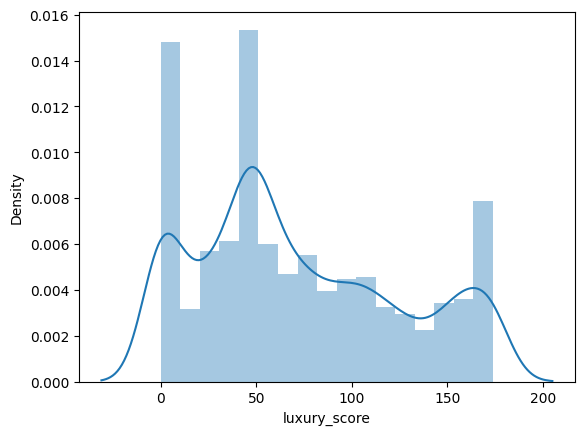

In [164]:
sns.distplot(df['luxury_score'])

<Axes: ylabel='luxury_score'>

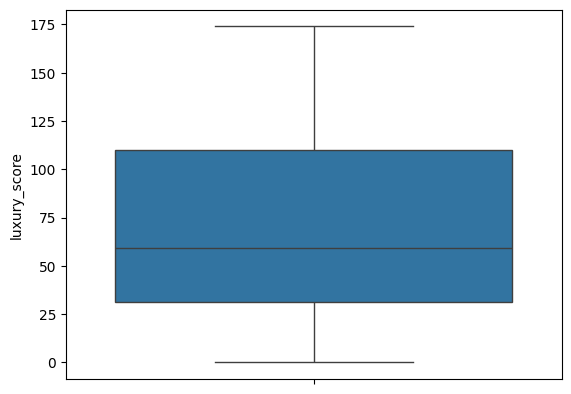

In [165]:
sns.boxplot(df['luxury_score'])

In [166]:
df.shape

(3590, 24)

In [167]:
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

In [168]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,smart world orchard,sector 61,1.41,12250.0,1151.0,Built Up area: 1150 (106.84 sq.m.),2.0,2.0,2,2.0,NaN,Under Construction,Situated in prime location of sector 61 on gol...,NaN,1150.0,NaN,1.0,0.0,0.0,0.0,0.0,1.0,76.0
1,flat,dlf the primus,sector 82a,2.85,10936.0,2606.0,Super Built up area 2606(242.11 sq.m.)Carpet a...,4.0,4.0,3+,2.0,North-East,New Property,A north facing 4 bhk resale flat is available ...,2606.0,NaN,1800.0,0.0,1.0,0.0,0.0,0.0,2.0,174.0
3,flat,shapoorji pallonji joyville gurugram,sector 102,0.95,10383.0,915.0,Built Up area: 915 (85.01 sq.m.)Carpet area: 8...,2.0,2.0,2,14.0,North-West,Undefined,"Club house, mini theater, squash court, swimmi...",NaN,915.0,858.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,house,independent,sector 7,1.20,11194.0,1072.0,Built Up area: 1072 (99.59 sq.m.),5.0,4.0,2,3.0,NaN,Undefined,5bhk residential house for resale in jyoti par...,NaN,1072.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,flat,hcbs sports ville,sohna road,0.27,4348.0,621.0,Built Up area: 619 (57.51 sq.m.),2.0,2.0,2,10.0,NaN,Relatively New,Raw flat as given by builder. Good location ne...,NaN,619.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,43.0


C:\Users\DELL\AppData\Local\Temp\ipykernel_14896\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

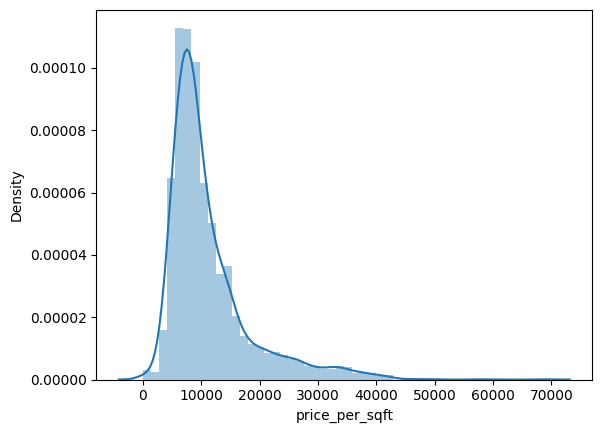

In [169]:
sns.distplot(df['price_per_sqft'])

<Axes: ylabel='price_per_sqft'>

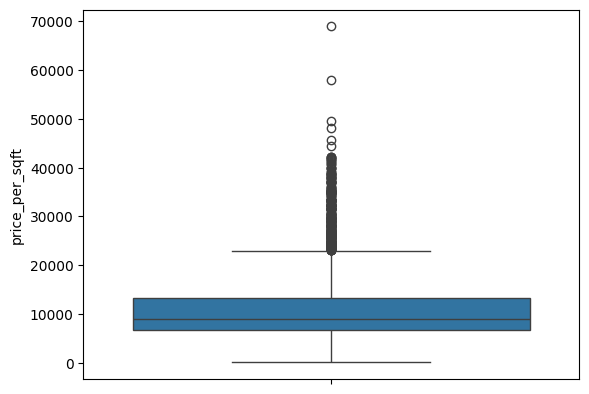

In [170]:
sns.boxplot(df['price_per_sqft'])

In [171]:
df[df['price_per_sqft'] > 42000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
48,flat,dlf the grove,sector 43,6.0,57971.0,1035.0,Carpet area: 2400 (222.97 sq.m.),4.0,4.0,2,1.0,South-West,Under Construction,Exclusive area on crest road on park lane drive,NaN,NaN,2400.0,0.0,1.0,0.0,0.0,0.0,0.0,49.0
127,house,sushant lok 1 builder floors,sector 43,13.0,48148.0,2700.0,Plot area 300(250.84 sq.m.),3.0,3.0,3+,4.0,North,New Property,Sushant lok a block gated line . Floor wise bu...,NaN,2700.0,NaN,0.0,0.0,0.0,1.0,0.0,0.0,7.0
696,house,independent,sector 26,19.0,42222.0,4500.0,Plot area 500(418.06 sq.m.),6.0,8.0,3+,3.0,East,Moderately Old,"Dlf phase 1, gurgaon, haryana\nBeautifully wel...",NaN,4500.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,103.0
1193,house,dlf city plots,sector 26,19.0,42054.0,4518.0,Plot area 502(419.74 sq.m.),6.0,6.0,3,2.0,East,Relatively New,North east facing a luxury independent house i...,NaN,4518.0,NaN,1.0,1.0,0.0,0.0,0.0,0.0,121.0
1507,house,independent,sector 25,13.0,45710.0,2844.0,Plot area 316(264.22 sq.m.),6.0,8.0,3+,NaN,NaN,Relatively New,An impeccable opportunity is here for those wh...,NaN,2844.0,NaN,1.0,1.0,1.0,1.0,0.0,2.0,0.0
2131,house,dlf city plots,sector 26,12.5,68985.0,1812.0,Plot area 360(301.01 sq.m.),4.0,5.0,2,2.0,North-East,Moderately Old,"4 bhk park facing, north east facing at very p...",NaN,3240.0,1812.0,1.0,1.0,0.0,0.0,0.0,0.0,121.0
2405,house,independent,sector 43,9.5,42222.0,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,5.0,5.0,3+,2.0,North-East,Relatively New,"Sushant lok 1 very prime location , this kothi...",NaN,300.0,250.0,0.0,1.0,0.0,1.0,0.0,0.0,88.0
2742,house,independent,sector 105,9.9,49500.0,2000.0,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2.0,2.0,2,3.0,North,Undefined,"2 bath, semi-Furnished, ground floor (Of 3), n...",NaN,2000.0,1800.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2889,house,independent,sector 26,20.0,44444.0,4500.0,Plot area 500(418.06 sq.m.),5.0,7.0,3+,3.0,West,Relatively New,"West facing kothi , area- 500 sq yard, \n5bhk-...",NaN,4500.0,NaN,0.0,1.0,0.0,1.0,0.0,2.0,97.0
3561,house,independent,sector 28,12.0,42194.0,2844.0,Plot area 316(264.22 sq.m.),4.0,5.0,3+,4.0,East,Relatively New,"Basement, gf, ff, sf, 4 bhk constructed duplex...",NaN,2844.0,NaN,0.0,1.0,1.0,1.0,0.0,0.0,60.0


In [176]:
x = df[df['price_per_sqft'] <= 20000]
(x['area']/x['bedRoom']).quantile(0.05)

252.95833333333334

In [177]:
df[(df['area']/df['bedRoom'])<252].sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1621,house,independent,manesar,0.80,6667.0,1200.0,Plot area 1200(111.48 sq.m.),8.0,8.0,2,1.0,NaN,Relatively New,Property earning monthly rent of 25000 appx.\n...,NaN,1200.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1265,flat,laxmi pareena,sector 99a,0.30,6667.0,450.0,Carpet area: 450 (41.81 sq.m.),2.0,1.0,0,12.0,North,Undefined,"2bhk affordable, ready to shift in sec 99a lax...",NaN,NaN,450.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2728,house,naman residency,sector 4,0.50,11111.0,450.0,Plot area 450(41.81 sq.m.),2.0,2.0,2,2.0,West,New Property,Modern house for sale complete with interior f...,NaN,450.0,NaN,1.0,1.0,0.0,1.0,1.0,1.0,14.0
2871,house,independent,sector 17,3.50,24306.0,1440.0,Built Up area: 160 (14.86 sq.m.),6.0,6.0,3+,3.0,North-West,Undefined,Best in class property available at sector 17 ...,NaN,160.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0
257,flat,gls avenue 51,sector 92,0.45,6000.0,750.0,Carpet area: 750 (69.68 sq.m.),3.0,3.0,1,10.0,North-East,Relatively New,You will get better aravalli view from flat ba...,NaN,NaN,750.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


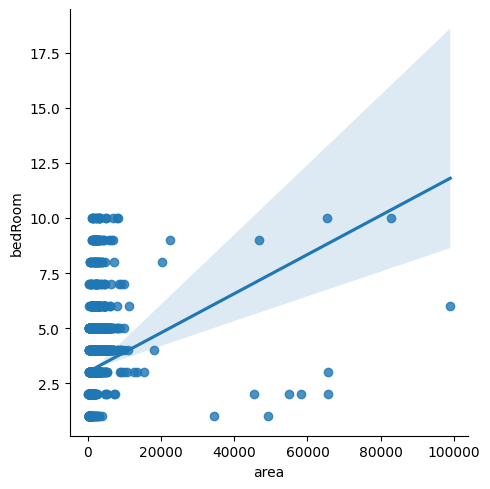

In [178]:
sns.lmplot(data=df, x='area', y='bedRoom')

In [180]:
df['area_room_ratio'] = df['area']/df['bedRoom']

In [181]:
(df[df['area_room_ratio']<252])['bedRoom'].value_counts()

bedRoom
2.0     53
3.0     38
5.0     28
4.0     17
6.0     17
9.0     14
8.0     12
7.0      8
10.0     7
1.0      1
Name: count, dtype: int64

In [182]:
df = df[df['area_room_ratio'] > 100]

In [183]:
outliers_df = df[(df['area_room_ratio']<252)&(df['bedRoom']>3)]

In [184]:
outliers_df['bedRoom'] = round(outliers_df['bedRoom']/outliers_df['floorNum'])

C:\Users\DELL\AppData\Local\Temp\ipykernel_14896\3450078040.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_df['bedRoom'] = round(outliers_df['bedRoom']/outliers_df['floorNum'])


In [185]:
df.update(outliers_df)

In [186]:
df['area_room_ratio'] = df['area']/df['bedRoom']

C:\Users\DELL\AppData\Local\Temp\ipykernel_14896\465686754.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['area_room_ratio'] = df['area']/df['bedRoom']


In [187]:
df[(df['area_room_ratio']<252)&(df['bedRoom']>4)]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
1122,house,independent,sector 12,2.50,13889.0,1800.0,Plot area 1800(167.23 sq.m.),9.0,5.0,2,1.0,South-East,Old Property,Size of property is 4045 Check out this 9 bhk ...,NaN,1800.0,NaN,0.0,0.0,0.0,1.0,0.0,1.0,8.0,200.000000
1144,house,independent,manesar,1.10,6173.0,1782.0,Plot area 1782(165.55 sq.m.),8.0,8.0,0,1.0,NaN,New Property,Building for rent purpose \n27k rent \n8 rooms...,NaN,1782.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0,222.750000
1236,house,independent,sector 2,0.98,9074.0,1080.0,Carpet area: 120 (100.34 sq.m.),9.0,4.0,3,1.0,South,Undefined,9bhk residential house for resale in palam vih...,NaN,NaN,120.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,120.000000
1250,house,independent,sector 3 phase 2,1.10,10000.0,1100.0,Built Up area: 1100 (102.19 sq.m.)Carpet area:...,5.0,4.0,2,1.0,East,Undefined,Two side open house near by all facilities ash...,NaN,1100.0,900.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,220.000000
1316,house,independent,sector 12,0.65,6500.0,1000.0,Carpet area: 1000 (92.9 sq.m.),6.0,2.0,3,1.0,NaN,Undefined,Best in class property available at maruti kun...,NaN,NaN,1000.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,166.666667
1325,house,independent,sector 11,3.50,15556.0,2250.0,Built Up area: 2250 (209.03 sq.m.),10.0,1.0,0,1.0,NaN,New Property,Looking for a good 10 bhk independent house in...,NaN,2250.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0,225.000000
1459,house,independent,sector 7,1.16,11717.0,990.0,Carpet area: 110 (91.97 sq.m.),5.0,4.0,2,1.0,North-East,Undefined,"Square plot, airy atmosphere, property ventila...",NaN,NaN,110.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,198.000000
1621,house,independent,manesar,0.80,6667.0,1200.0,Plot area 1200(111.48 sq.m.),8.0,8.0,2,1.0,NaN,Relatively New,Property earning monthly rent of 25000 appx.\n...,NaN,1200.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0,150.000000
2123,house,independent,sector 105,1.10,12222.0,900.0,Carpet area: 900 (83.61 sq.m.),6.0,4.0,1,1.0,South-West,Undefined,Best in class property available at rajendra p...,NaN,NaN,900.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,150.000000
2190,house,"bhim nagar, sector 6",sector 6,0.85,14096.0,603.0,Plot area 67(6.22 sq.m.),5.0,2.0,2,1.0,NaN,Old Property,"Hello all,This is good property where we spent...",NaN,67.0,NaN,0.0,0.0,0.0,1.0,0.0,1.0,29.0,120.600000


In [188]:
df.shape

(3570, 25)

In [189]:
df = df[~((df['area_room_ratio']<252)&(df['bedRoom']>4))]

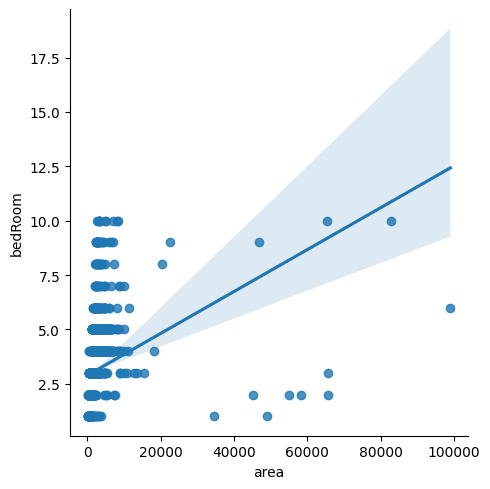

In [190]:
sns.lmplot(data=df, x='area', y='bedRoom')

In [191]:
df.shape

(3557, 25)

In [192]:
df.head() 

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,smart world orchard,sector 61,1.41,12250.0,1151.0,Built Up area: 1150 (106.84 sq.m.),2.0,2.0,2,2.0,NaN,Under Construction,Situated in prime location of sector 61 on gol...,NaN,1150.0,NaN,1.0,0.0,0.0,0.0,0.0,1.0,76.0,575.5
1,flat,dlf the primus,sector 82a,2.85,10936.0,2606.0,Super Built up area 2606(242.11 sq.m.)Carpet a...,4.0,4.0,3+,2.0,North-East,New Property,A north facing 4 bhk resale flat is available ...,2606.0,NaN,1800.0,0.0,1.0,0.0,0.0,0.0,2.0,174.0,651.5
3,flat,shapoorji pallonji joyville gurugram,sector 102,0.95,10383.0,915.0,Built Up area: 915 (85.01 sq.m.)Carpet area: 8...,2.0,2.0,2,14.0,North-West,Undefined,"Club house, mini theater, squash court, swimmi...",NaN,915.0,858.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,457.5
4,house,independent,sector 7,1.20,11194.0,1072.0,Built Up area: 1072 (99.59 sq.m.),2.0,4.0,2,3.0,NaN,Undefined,5bhk residential house for resale in jyoti par...,NaN,1072.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0,536.0
5,flat,hcbs sports ville,sohna road,0.27,4348.0,621.0,Built Up area: 619 (57.51 sq.m.),2.0,2.0,2,10.0,NaN,Relatively New,Raw flat as given by builder. Good location ne...,NaN,619.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,43.0,310.5


In [193]:
 df.to_csv('gurgoan_properties_outliers_treated.csv', index=False)